# Preparation

Make ROOT independent of where the Jupyter server is launched:

In [1]:
from pathlib import Path

def find_project_root(start: Path, markers=("pyproject.toml", ".git")):
    for p in [start] + list(start.parents):
        if any((p / m).exists() for m in markers):
            return p
    raise RuntimeError("Project root not found")

ROOT = find_project_root(Path.cwd())

print(ROOT)

/Users/albin/git/gh/responsio-accentuum


In [2]:
from_cache = True

We focus on the 33 fully responding odes. 

We want to make the distribution of strophicities in one metrically-responding-baseline statistic pass equal to the distribution of triadic strophicities in Pindar, as calculated below:

In [3]:
import xml.etree.ElementTree as ET

FOLDERS = {
    "triads": ROOT / "data" / "compiled" / "triads",
    "strophes": ROOT / "data" / "compiled" / "strophes"
}

def collect_ids(folder: Path) -> set[str]:
    ids: set[str] = set()
    for xml_path in folder.glob("*.xml"):
        try:
            tree = ET.parse(xml_path)
            for elem in tree.iter():
                resp_id = elem.attrib.get("responsion")
                if resp_id:
                    ids.add(resp_id)
        except Exception as exc:
            print(f"Warning: failed to parse {xml_path}: {exc}")
    return ids


results: dict[str, set[str]] = {}
for name, folder in FOLDERS.items():
    ids = collect_ids(folder)
    results[name] = ids

tri = results["triads"]
stro = results["strophes"]

fully_triadic_odes = (tri & stro)   # triadic-simple responsion type

In [4]:
from collections import defaultdict
from responsio_accentuum import get_strophicity

responsion_counts = get_strophicity(responsion_type="triadic-simple")
responsion_counts = {rid: count for rid, count in responsion_counts.items() if rid in fully_triadic_odes}

# We check the number of odes for every strophicity
strophicity_counts = defaultdict(int)
for strophicity in responsion_counts.values():
    strophicity_counts[strophicity] += 1

strophicity_counts = dict(strophicity_counts)
strophicity_weights = {s: count/sum(strophicity_counts.values()) for s, count in strophicity_counts.items()}

for strophicity, count in sorted(strophicity_counts.items()):
    print(f"{strophicity}-strophic: {count} odes ({strophicity_weights[strophicity]*100:.1f} percent); hence we need 6 * {count} = {6*count} permutations of data/compiled/baselines/baseline_aristophanes/tetra(and tri-)meter_{strophicity}.xml")

strophicities = sorted(strophicity_counts.keys())
print(f"\nList to be used: {sorted(strophicities)}")
print(f"\nDict to be used: {strophicity_counts}")

3-strophic: 10 odes (30.3 percent); hence we need 6 * 10 = 60 permutations of data/compiled/baselines/baseline_aristophanes/tetra(and tri-)meter_3.xml
4-strophic: 10 odes (30.3 percent); hence we need 6 * 10 = 60 permutations of data/compiled/baselines/baseline_aristophanes/tetra(and tri-)meter_4.xml
5-strophic: 12 odes (36.4 percent); hence we need 6 * 12 = 72 permutations of data/compiled/baselines/baseline_aristophanes/tetra(and tri-)meter_5.xml
13-strophic: 1 odes (3.0 percent); hence we need 6 * 1 = 6 permutations of data/compiled/baselines/baseline_aristophanes/tetra(and tri-)meter_13.xml

List to be used: [3, 4, 5, 13]

Dict to be used: {4: 10, 3: 10, 5: 12, 13: 1}


Prepare first version of all the higher un-manual strophicities:

In [5]:
import os
import re

def make_higher_strophicity(xml_file_path, flavour="tetrameter"):
    xml_path = Path(xml_file_path)
    text = xml_path.read_text(encoding="utf8")

    # extract all <l> elements from ALL canticum blocks
    lines = re.findall(r"<l\b[^>]*>.*?</l>", text, flags=re.DOTALL)                     # the DOTALL flag makes the DOT . find ALL chars including \n
    # filter to unique <l> elements based on inner text
    seen = set()
    unique_lines = []
    line_metadata = []  # Track (canticum, original_strophe, line_in_strophe) for each line

    for l in lines:
        inner = re.sub(r"<l\b[^>]*>|</l>", "", l, flags=re.DOTALL)                      # the DOTALL flag makes the DOT . find ALL chars including \n
        if inner not in seen:
            seen.add(inner)
            unique_lines.append(l)

            # Parse the 'n' attribute to extract metadata (used only for tetrameter constraints)
            match = re.search(r' n="([^"]*)"', l)
            if match:
                n_val = match.group(1)
                parts = n_val.split('_')
                try:
                    canticum = parts[0]
                    strophe_line_part = parts[1]
                    original_strophe = int(strophe_line_part.split('-')[0])
                    line_in_strophe = int(strophe_line_part.split('-')[1])
                    line_metadata.append((canticum, original_strophe, line_in_strophe))
                except Exception:
                    line_metadata.append(None)
            else:
                line_metadata.append(None)

    lines = unique_lines

    # Build responsion groups: (canticum, line_in_strophe) -> list of line indices
    responsion_groups = {}
    for idx, meta in enumerate(line_metadata):
        if meta:
            canticum, original_strophe, line_in_strophe = meta
            key = (canticum, line_in_strophe)
            if key not in responsion_groups:
                responsion_groups[key] = []
            responsion_groups[key].append(idx)

    # Filter to only groups where lines originally responded (>1 line per group)
    responsion_groups = {k: v for k, v in responsion_groups.items() if len(v) > 1}

    # We only need baselines with strophicities present in Pindar (and 2 is the source)
    for n_strophes in [3, 4, 5, 6, 7, 11, 12, 13]:

        # split lines evenly — truncate excess so all strophes have equal line counts
        chunk_size = len(lines) // n_strophes
        usable = chunk_size * n_strophes
        lines_to_use = lines[:usable]

        if flavour == "tetrameter":
            # Distribute lines using constraint-aware greedy algorithm.
            # Ensure originally responding lines do not end up at the same position in different new strophes.
            chunks = [[] for _ in range(n_strophes)]
            position_tracker = [[None] * chunk_size for _ in range(n_strophes)]  # Tracks original line index at each position
            used_indices = set()

            for strophe_idx in range(n_strophes):
                for pos_idx in range(chunk_size):
                    # Find a line to place at this position that does not violate constraints.
                    placed = False
                    for line_idx in range(len(lines_to_use)):
                        if line_idx in used_indices:
                            continue

                        # Check if placing this line violates the responsion constraint.
                        violates = False
                        for prev_strophe_idx in range(strophe_idx):
                            prev_line_idx_at_pos = position_tracker[prev_strophe_idx][pos_idx]
                            if prev_line_idx_at_pos is not None:
                                # Check if these two lines originally responded.
                                for responding_group in responsion_groups.values():
                                    if line_idx in responding_group and prev_line_idx_at_pos in responding_group:
                                        violates = True
                                        break
                                if violates:
                                    break

                        if not violates:
                            chunks[strophe_idx].append(lines_to_use[line_idx])
                            position_tracker[strophe_idx][pos_idx] = line_idx
                            used_indices.add(line_idx)
                            placed = True
                            break

                    if not placed:
                        raise RuntimeError(
                            f"Constraint-satisfying placement failed for {xml_path.name} ({flavour}), "
                            f"{n_strophes}-strophic output, strophe {strophe_idx + 1}, "
                            f"line position {pos_idx + 1}. No unused line can be placed "
                            "without recreating original responsion."
                        )
        else:
            # Trimeter has no usable n-metadata for anti-responsion constraints; keep unconstrained chunking.
            chunks = []
            i = 0
            for _ in range(n_strophes):
                chunks.append(lines_to_use[i:i + chunk_size])
                i += chunk_size

        # build strophe blocks
        strophe_blocks = []
        for idx, chunk in enumerate(chunks):

            typ = "strophe"

            # indent the <l> lines
            indented_lines = "\n".join("          " + l for l in chunk)

            if flavour == "tetrameter":
                block = (
                    f'        <strophe type="{typ}" responsion="lyricbaseline{n_strophes:02d}">\n'
                    + indented_lines +
                    "\n        </strophe>"
                )

            elif flavour == "trimeter":
                block = (
                    f'        <strophe type="{typ}" responsion="dialoguebaseline{n_strophes:02d}">\n'
                    + indented_lines +
                    "\n        </strophe>"
                )

            strophe_blocks.append(block)

        # assemble new canticum
        new_canticum = (
            "      <canticum>\n"
            + "\n".join(strophe_blocks)
            + "\n      </canticum>"
        )

        # update title
        if flavour == "tetrameter":
            new_text = re.sub(
                r"<title>.*?</title>",
                f"<title>{n_strophes}-strophic Tetrameter Baseline</title>",
                text,
                flags=re.DOTALL
            )

        elif flavour == "trimeter":
            new_text = re.sub(
                r"<title>.*?</title>",
                f"<title>{n_strophes}-strophic Trimeter (Dialogue) Baseline</title>",
                text,
                flags=re.DOTALL
            )

        # remove all original canticum blocks cleanly
        new_text = re.sub(
            r"\s*<canticum>.*?</canticum>\s*",
            "\n",
            new_text,
            flags=re.DOTALL
        )

        # insert the new canticum before </body>
        new_text = re.sub(
            r"\s*</body>",
            "\n" + new_canticum + "\n    </body>",
            new_text,
            count=1
        )

        # write output
        out_path = xml_path.with_name(f"{flavour}_{n_strophes}.xml")
        out_path.write_text(new_text, encoding="utf8")

if not os.path.exists(ROOT / "data/cache/aristophanes_bl_statistics.pkl"):
    make_higher_strophicity(ROOT / "data" / "compiled" / "baselines" / "baseline_aristophanes" / "tetrameter_2.xml", "tetrameter")
    make_higher_strophicity(ROOT / "data" / "compiled" / "baselines" / "baseline_aristophanes" / "trimeter_2.xml", "trimeter")

We need to check that all the files are metrically sound.

In [6]:
from lxml import etree
from responsio_accentuum import canonical_sylls, metrically_responding_lines_polystrophic

baseline_files = []
for n in [2, 3, 4, 5, 6, 7, 11, 12, 13]:
    tetrameter = ROOT / f"data/compiled/baselines/baseline_aristophanes/tetrameter_{n}.xml"
    trimeter = ROOT / f"data/compiled/baselines/baseline_aristophanes/trimeter_{n}.xml"
    baseline_files.append(tetrameter)
    baseline_files.append(trimeter)

all_ok = True

for bf in baseline_files:
    tree = etree.parse(str(bf))
    strophes = tree.xpath('//strophe')

    # Group strophes by @responsion
    responsion_groups = {}
    for s in strophes:
        rid = s.get('responsion')
        responsion_groups.setdefault(rid, []).append(s)

    for rid, group in responsion_groups.items():
        # Get lines from each strophe
        strophe_lines = [s.findall('l') for s in group]
        n_lines = [len(ls) for ls in strophe_lines]

        # Check all strophes have same number of lines
        if len(set(n_lines)) != 1:
            print(f"FAIL {bf.name} [{rid}]: strophes have different line counts: {n_lines}")
            all_ok = False
            continue

        # For each line position, check canonical_sylls length and metrical responsion
        for i in range(n_lines[0]):
            responding = [ls[i] for ls in strophe_lines]
            lengths = [len(canonical_sylls(l)) for l in responding]

            if len(set(lengths)) != 1:
                line_ns = [l.get('n', '?') for l in responding]
                print(f"FAIL {bf.name} [{rid}] pos {i}: canonical_sylls lengths differ: {dict(zip(line_ns, lengths))}")
                all_ok = False

            if not metrically_responding_lines_polystrophic(*responding):
                line_ns = [l.get('n', '?') for l in responding]
                print(f"FAIL {bf.name} [{rid}] pos {i}: metrical responsion fails for lines {line_ns}")
                all_ok = False

if all_ok:
    print("All baseline files are metrically sound!")

All baseline files are metrically sound!


Define the permutation functions...

In [7]:
import random
import re

from lxml import etree
from typing import Iterator

baseline_files = []
for n in strophicities:
    tetrameter = ROOT / f"data/compiled/baselines/baseline_aristophanes/tetrameter_{n}.xml"
    trimeter = ROOT / f"data/compiled/baselines/baseline_aristophanes/trimeter_{n}.xml"
    baseline_files.append(tetrameter)
    baseline_files.append(trimeter)

# Make permutated versions of all canticum elements in each of the six files.
# Important points:
# - What's permuted are the l element orderings of each of its strophes.
# - It is key that the permutation is different for all strophes inside the same canticum, so responsion is not conserved, otherwise the permutation test will not work

temp_dir = ROOT / "data/compiled/baselines/baseline_aristophanes/temp_permutations"
temp_dir.mkdir(parents=True, exist_ok=True)

canticum_re = re.compile(r"(<canticum\b[^>]*>)(.*?)(</canticum>)", re.S)
strophe_re = re.compile(r"(<strophe\b[^>]*>)(.*?)(</strophe>)", re.S)

def parse_source_key_from_l_line(l_line: str) -> tuple[str, int] | None:
    """Return (source_canticum, source_internal_line_nr) parsed from @n, else None."""
    m = re.search(r'\bn="([^"]+)"', l_line)
    if not m:
        return None
    n_val = m.group(1)
    parts = n_val.split("_")
    if len(parts) < 2:
        return None
    try:
        source_canticum = parts[0]
        strophe_internal = parts[1]  # e.g. 1-3
        internal_line_nr = int(strophe_internal.split("-")[1])
        return (source_canticum, internal_line_nr)
    except Exception:
        return None

def extract_strophe_structures(canticum_body: str):
    """Parse strophe bodies and keep mutable split-lines representation for replacement."""
    structures = []
    for sm in strophe_re.finditer(canticum_body):
        strophe_open, strophe_body, strophe_close = sm.groups()
        lines = strophe_body.splitlines(keepends=True)
        l_indices = [i for i, line in enumerate(lines) if re.search(r"<l\b", line)]
        structures.append(
            {
                "open": strophe_open,
                "close": strophe_close,
                "lines": lines,
                "l_indices": l_indices,
            }
        )
    return structures

def tetrameter_constraint_holds(text: str) -> bool:
    """Check: within each output canticum, same line position across strophes cannot reuse same source key."""
    for c_match in canticum_re.finditer(text):
        c_body = c_match.group(2)
        strophes = extract_strophe_structures(c_body)
        if not strophes:
            continue

        max_positions = max((len(s["l_indices"]) for s in strophes), default=0)
        for pos_idx in range(max_positions):
            seen_keys = set()
            for s in strophes:
                if pos_idx >= len(s["l_indices"]):
                    continue
                line_idx = s["l_indices"][pos_idx]
                l_line = s["lines"][line_idx]
                key = parse_source_key_from_l_line(l_line)
                if key is None:
                    continue
                if key in seen_keys:
                    return False
                seen_keys.add(key)
    return True

def shuffle_strophe_lines(strophe_body: str, rng: random.Random) -> str:
    # Trimeter path: original unconstrained per-strophe shuffle.
    lines = strophe_body.splitlines(keepends=True)

    l_indices = [i for i, line in enumerate(lines) if re.search(r"<l\b", line)]

    if len(l_indices) <= 1:
        return strophe_body

    l_lines = [lines[i] for i in l_indices]
    rng.shuffle(l_lines)

    for idx, new_line in zip(l_indices, l_lines):
        lines[idx] = new_line

    return "".join(lines)

def permute_tetrameter_once(text: str, rng: random.Random, max_attempts: int = 200) -> str:
    # Build mutable canticum/strophe structures.
    canticum_structs = []
    all_l_lines = []

    for c_idx, c_match in enumerate(canticum_re.finditer(text)):
        c_open, c_body, c_close = c_match.groups()
        strophes = extract_strophe_structures(c_body)

        for s in strophes:
            for li in s["l_indices"]:
                all_l_lines.append(s["lines"][li])

        canticum_structs.append(
            {
                "open": c_open,
                "close": c_close,
                "body": c_body,
                "strophes": strophes,
            }
        )

    if len(all_l_lines) <= 1:
        return text

    source_keys = [parse_source_key_from_l_line(l) for l in all_l_lines]

    # Define target slots as (canticum_index, strophe_index, position_in_strophe).
    slots = []
    for c_idx, c in enumerate(canticum_structs):
        for s_idx, s in enumerate(c["strophes"]):
            for pos_idx in range(len(s["l_indices"])):
                slots.append((c_idx, s_idx, pos_idx))

    if len(slots) != len(all_l_lines):
        raise RuntimeError("Internal mismatch: number of slots differs from number of lines")

    for _ in range(max_attempts):
        remaining = list(range(len(all_l_lines)))
        rng.shuffle(remaining)

        used_source_keys = {}  # (canticum_idx, pos_idx) -> set of source keys
        assignment = {}         # (canticum_idx, s_idx, pos_idx) -> line_pool_idx
        success = True

        for c_idx, s_idx, pos_idx in slots:
            group_key = (c_idx, pos_idx)
            group_used = used_source_keys.setdefault(group_key, set())

            chosen_pos = None
            for rem_i, pool_idx in enumerate(remaining):
                src_key = source_keys[pool_idx]
                if src_key is not None and src_key in group_used:
                    continue
                chosen_pos = rem_i
                break

            if chosen_pos is None:
                success = False
                break

            chosen_pool_idx = remaining.pop(chosen_pos)
            assignment[(c_idx, s_idx, pos_idx)] = chosen_pool_idx
            src_key = source_keys[chosen_pool_idx]
            if src_key is not None:
                group_used.add(src_key)

        if not success:
            continue

        # Apply assignment to mutable strophe lines.
        for (c_idx, s_idx, pos_idx), pool_idx in assignment.items():
            s = canticum_structs[c_idx]["strophes"][s_idx]
            line_array_idx = s["l_indices"][pos_idx]
            s["lines"][line_array_idx] = all_l_lines[pool_idx]

        # Rebuild each canticum body while preserving non-strophe text segments.
        rebuilt_canticum_texts = []
        for c in canticum_structs:
            rebuilt_strophes = [
                s["open"] + "".join(s["lines"]) + s["close"]
                for s in c["strophes"]
            ]
            rebuilt_iter = iter(rebuilt_strophes)
            new_body = strophe_re.sub(lambda m: next(rebuilt_iter), c["body"])
            rebuilt_canticum_texts.append(c["open"] + new_body + c["close"])

        # Rebuild full text while preserving non-canticum segments.
        c_iter = iter(rebuilt_canticum_texts)
        new_text = canticum_re.sub(lambda m: next(c_iter), text)

        # Final sanity check for the tetrameter-specific constraint.
        assert tetrameter_constraint_holds(new_text), "Tetrameter anti-responsion constraint violated"
        return new_text

    raise RuntimeError(
        "Could not find a tetrameter permutation satisfying anti-responsion constraints "
        f"after {max_attempts} attempts"
    )

def permute_text_once(text: str, rng: random.Random, flavour: str = "trimeter") -> str:
    if flavour == "tetrameter":
        return permute_tetrameter_once(text, rng)

    # Trimeter behavior remains unchanged.
    def repl(match):
        open_tag, body, close_tag = match.groups()
        new_body = shuffle_strophe_lines(body, rng)
        return open_tag + new_body + close_tag

    return strophe_re.sub(repl, text)

def permutation_file_is_usable(path: Path) -> bool:

    return path.exists() and path.stat().st_size > 0


def write_permutation_atomically(path: Path, text: str) -> None:

    if not text.strip():

        raise ValueError(f"Refusing to write empty permutation XML: {path}")

    tmp_path = path.with_name(f".{path.name}.tmp")

    tmp_path.write_text(text, encoding="utf-8")

    try:

        etree.parse(str(tmp_path))

    except Exception:

        tmp_path.unlink(missing_ok=True)

        raise

    tmp_path.replace(path)

def iter_permuted_texts(

    xml_path: Path,

    n_permutations: int,

    seed: int | None = None,

    skip_existing: bool = False,

    output_dir: Path = None,

    stem: str = None,

    flavour: str | None = None,

    ) -> Iterator[tuple[int, str]]:

    text = xml_path.read_text(encoding="utf-8")

    rng = random.Random(seed)



    inferred_flavour = flavour

    if inferred_flavour is None:

        if xml_path.stem.startswith("tetrameter"):

            inferred_flavour = "tetrameter"

        else:

            inferred_flavour = "trimeter"



    for i in range(1, n_permutations + 1):

        # Always generate the i-th permutation so the RNG state stays aligned

        # even when an existing output file lets us skip writing it.

        permuted = permute_text_once(text, rng, flavour=inferred_flavour)

        if inferred_flavour == "tetrameter":

            assert tetrameter_constraint_holds(permuted), "Tetrameter anti-responsion constraint violated"



        if skip_existing and output_dir is not None and stem is not None:

            out_path = output_dir / f"{stem}_perm_{i:05d}.xml"

            if permutation_file_is_usable(out_path):

                continue



        yield i, permuted

def save_permutations(
    xml_path: Path,
    n_permutations: int,
    output_dir: Path,
    seed: int | None = None,
    ) -> None:
    output_dir.mkdir(parents=True, exist_ok=True)
    stem = xml_path.stem
    flavour = "tetrameter" if stem.startswith("tetrameter") else "trimeter"
    for i, permuted_text in iter_permuted_texts(
        xml_path,
        n_permutations,
        seed=seed,
        skip_existing=True,
        output_dir=output_dir,
        stem=stem,
        flavour=flavour,
    ):
        out_path = output_dir / f"{stem}_perm_{i:05d}.xml"
        write_permutation_atomically(out_path, permuted_text)

def print_test_permutation(xml_path: Path) -> None:
    flavour = "tetrameter" if xml_path.stem.startswith("tetrameter") else "trimeter"
    text = next(iter_permuted_texts(xml_path, 1, seed=42, flavour=flavour))[1]
    print(text[:10000])

In [8]:
# Test print of one permutation to inspect
print_test_permutation(baseline_files[1])

<?xml version='1.0' encoding='UTF-8'?>
<TEI>
  <teiHeader>
    <fileDesc>
      <titleStmt>
        <title>3-strophic Trimeter (Dialogue) Baseline</title>
        <author>Aristophanes</author>
      </titleStmt>
    </fileDesc>
  </teiHeader>
  <text>
    <body>
      <canticum>
        <strophe type="strophe" responsion="dialoguebaseline03">
          <l n="8" metre=""><syll weight="light" resolution="True">δι</syll><syll weight="light" resolution="True">ὰ</syll> <syll weight="heavy">τοῦ</syll><syll weight="light">το</syll> <syll weight="heavy">τοὔρ</syll><syll weight="light" anceps="True">γο</syll><syll weight="heavy">ν· ἄξ</syll><syll weight="light">ι</syll><syll weight="heavy">ον</syll> <syll weight="light" anceps="True">γὰ</syll><syll weight="heavy">ρ Ἑλ</syll><syll weight="light">λά</syll><syll weight="light" brevis_in_longo="True">δι</syll>. </l>
          <l n="11" metre=""><syll weight="light" resolution="True">ὁ</syll> <syll weight="light" resolution="True">δ' ἀ</syll><syll w

...and time to permute and save to disk! We permute each class enough times to maintain the Pindaric corpus distribution of strophicities.

In [9]:
if not from_cache:

    import hashlib
    import re
    from tqdm import tqdm

    # determines number of output expected test statistics
    base_cycles = 10_000

    generated_paths = []
    for file in tqdm(baseline_files):
        m = re.search(r"_(\d+)\.xml$", file.name)
        if not m:
            raise ValueError(f"Could not infer strophicity from filename: {file.name}")

        strophicity = int(m.group(1))
        if strophicity not in strophicity_counts:
            raise ValueError(f"Unexpected strophicity {strophicity} in {file.name}")

        n_permutations = base_cycles * strophicity_counts[strophicity]
        save_permutations(
            file,
            n_permutations=n_permutations,
            output_dir=temp_dir / file.stem,
            seed=1453,
        )
        generated_paths.extend(sorted((temp_dir / file.stem).glob("*.xml")))

    # Quick uniqueness check of generated XML content
    hash_to_files = {}
    for path in tqdm(generated_paths):
        digest = hashlib.sha256(path.read_bytes()).hexdigest()
        hash_to_files.setdefault(digest, []).append(path)

    duplicate_groups = [paths for paths in hash_to_files.values() if len(paths) > 1]
    if duplicate_groups:
        print(f"Found {len(duplicate_groups)} duplicate content group(s) among generated XMLs.")
        for group in duplicate_groups[:5]:
            print("  Duplicate group:")
            for p in group:
                print(f"    - {p}")
    else:
        print(f"All generated XMLs are unique by content ({len(generated_paths)} files checked).")

# Test statistics

The plan is this: to calculate one test statistic we collect 33 songs by choosing baselines that mirror the strophicity distribution of the actual corpus, i.e. we choose more baselines with strophicities that are more represented in the observed corpus.

We then repeat this 10k times.

The final value presented in the table in the article will be the mean of these 10k test statistics, just like for the shape-preserving baselines.

In [10]:
########################
test_statistics = 10_000
########################

For speed, the four lists of expected test statistics are calculated with multiprocessing in the script `scripts/calculate_expected_aristophanes.py`:


    expected_statistics_tetrameter_by_position
    expected_statistics_trimeter_by_position
    expected_statistics_tetrameter_by_song
    expected_statistics_trimeter_by_song


In [11]:
import os
import pickle

if os.path.exists(ROOT / "data/cache/aristophanes_bl_statistics.pkl"):
    with open(ROOT / "data/cache/aristophanes_bl_statistics.pkl", "rb") as f:
        stats = pickle.load(f)

expected_statistics_tetrameter_by_position = stats["tetrameter_by_position"]
expected_statistics_trimeter_by_position = stats["trimeter_by_position"]
expected_statistics_tetrameter_by_song = stats["tetrameter_by_song"]
expected_statistics_trimeter_by_song = stats["trimeter_by_song"]

# Calculate final mean statistic across the corpora
mean = sum(expected_statistics_tetrameter_by_position.values()) / len(expected_statistics_tetrameter_by_position)


print("#" * 40)
print("TETRAMETER BY POSITION")
print("#" * 40)
print()

print(f"Mean expected statistic across 10k corpora: \033[92m{mean:.4f}\033[0m\n")
print(f"Minimum: \033[92m{min(expected_statistics_tetrameter_by_position.values()):.4f}\033[0m")
print(f"Maximum: \033[92m{max(expected_statistics_tetrameter_by_position.values()):.4f}\033[0m")

# Calculate final mean statistic across the corpora
mean = sum(expected_statistics_trimeter_by_position.values()) / len(expected_statistics_trimeter_by_position)

print()
print("#" * 40)
print("TRIMETER BY POSITION")
print("#" * 40)
print()

print(f"Mean expected statistic across 10k corpora: \033[92m{mean:.4f}\033[0m\n")
print(f"Minimum: \033[92m{min(expected_statistics_trimeter_by_position.values()):.4f}\033[0m")
print(f"Maximum: \033[92m{max(expected_statistics_trimeter_by_position.values()):.4f}\033[0m")

# Calculate final mean statistic across the corpora
mean = sum(
    sum(statistics) / len(statistics)
    for statistics in expected_statistics_tetrameter_by_song.values()
) / len(expected_statistics_tetrameter_by_song)

print()
print("#" * 40)
print("TETRAMETER BY SONG")
print("#" * 40)
print()

print(f"Mean expected statistic across 10k corpora: \033[92m{mean:.4f}\033[0m\n")
print(f"Minimum: \033[92m{min(sum(statistics) / len(statistics) for statistics in expected_statistics_tetrameter_by_song.values()):.4f}\033[0m")
print(f"Maximum: \033[92m{max(sum(statistics) / len(statistics) for statistics in expected_statistics_tetrameter_by_song.values()):.4f}\033[0m")

# Calculate final mean statistic across the corpora
mean = sum(
    sum(statistics) / len(statistics)
    for statistics in expected_statistics_trimeter_by_song.values()
) / len(expected_statistics_trimeter_by_song)

print()
print("#" * 40)
print("TRIMETER BY SONG")
print("#" * 40)
print()

print(f"Mean expected statistic across 10k corpora: \033[92m{mean:.4f}\033[0m\n")
print(f"Minimum: \033[92m{min(sum(statistics) / len(statistics) for statistics in expected_statistics_trimeter_by_song.values()):.4f}\033[0m")
print(f"Maximum: \033[92m{max(sum(statistics) / len(statistics) for statistics in expected_statistics_trimeter_by_song.values()):.4f}\033[0m")


########################################
TETRAMETER BY POSITION
########################################

Mean expected statistic across 10k corpora: 0.5990

Minimum: 0.5858
Maximum: 0.6153

########################################
TRIMETER BY POSITION
########################################

Mean expected statistic across 10k corpora: 0.5810

Minimum: 0.5634
Maximum: 0.6004

########################################
TETRAMETER BY SONG
########################################

Mean expected statistic across 10k corpora: 0.5974

Minimum: 0.5856
Maximum: 0.6120

########################################
TRIMETER BY SONG
########################################

Mean expected statistic across 10k corpora: 0.5790

Minimum: 0.5634
Maximum: 0.5960


# One-sided permutation test

## T_obs_triads

The observed values are compared to the distributions of expected statistics to get p-values.

In [12]:
T_obs_triads_position = 0.5276
T_obs_triads_song = 0.5281

In [13]:
T_exp_tetrameter_by_position = list(expected_statistics_tetrameter_by_position.values())
T_exp_trimeter_by_position = list(expected_statistics_trimeter_by_position.values())

T_exp_tetrameter_by_song = [
    sum(statistics) / len(statistics)
    for statistics in expected_statistics_tetrameter_by_song.values()
]
T_exp_trimeter_by_song = [
    sum(statistics) / len(statistics)
    for statistics in expected_statistics_trimeter_by_song.values()
]

In [14]:
import numpy as np

def permutation_p_value(T_obs, baseline):
    baseline_arr = np.asarray(baseline)
    ge_count = np.sum(baseline_arr >= T_obs) # ge = greater than or equal to
    return (1 + ge_count) / (1 + baseline_arr.size) # convention to add 1 to numerator and denominator to avoid zero p-value (source: https://en.wikipedia.org/wiki/P-value#Permutation_tests)

p_tetrameter_position = permutation_p_value(T_obs_triads_position, T_exp_tetrameter_by_position)
p_trimeter_position = permutation_p_value(T_obs_triads_position, T_exp_trimeter_by_position)
p_tetrameter_song = permutation_p_value(T_obs_triads_song, T_exp_tetrameter_by_song)
p_trimeter_song = permutation_p_value(T_obs_triads_song, T_exp_trimeter_by_song)

print(f"p_tetrameter_position (triads vs tetrameter baseline): \033[1m{p_tetrameter_position:.30f}\033[0m")
print(f"p_trimeter_position (triads vs trimeter baseline): \033[1m{p_trimeter_position:.30f}\033[0m")
print(f"p_tetrameter_song (triads vs tetrameter baseline): \033[1m{p_tetrameter_song:.30f}\033[0m")
print(f"p_trimeter_song (triads vs trimeter baseline): \033[1m{p_trimeter_song:.30f}\033[0m")

p_tetrameter_position (triads vs tetrameter baseline): 1.000000000000000000000000000000
p_trimeter_position (triads vs trimeter baseline): 1.000000000000000000000000000000
p_tetrameter_song (triads vs tetrameter baseline): 1.000000000000000000000000000000
p_trimeter_song (triads vs trimeter baseline): 1.000000000000000000000000000000


### Z-score

We can also measure the effect size by computing the z-score of the observed statistic relative to the baseline distribution:

$$z_{\text{emp}} = \frac{T_{\text{obs}} - \mu_0}{\sigma_0}$$

Source: https://en.wikipedia.org/wiki/Permutation_test#One-sided_permutation_test

In [15]:
import numpy as np

def z_score(T_obs, baseline):
    arr = np.asarray(baseline, dtype=float)
    mu = arr.mean()
    sigma = arr.std(ddof=0)
    return (float(T_obs) - mu) / sigma if sigma != 0 else np.nan

z_tetrameter_position = z_score(T_obs_triads_position, T_exp_tetrameter_by_position)
z_trimeter_position = z_score(T_obs_triads_position, T_exp_trimeter_by_position)
z_tetrameter_song = z_score(T_obs_triads_song, T_exp_tetrameter_by_song)
z_trimeter_song = z_score(T_obs_triads_song, T_exp_trimeter_by_song)

print(f"z_trimeter_position (triads vs trimeter baseline):   {z_trimeter_position:>8.3g}")
print(f"z_trimeter_song (triads vs trimeter baseline):       {z_trimeter_song:>8.3g}")
print()
print(f"z_tetrameter_position (triads vs tetrameter baseline): {z_tetrameter_position:>6.3g}")
print(f"z_tetrameter_song (triads vs tetrameter baseline):     {z_tetrameter_song:>6.3g}")

z_trimeter_position (triads vs trimeter baseline):      -11.6
z_trimeter_song (triads vs trimeter baseline):          -12.1

z_tetrameter_position (triads vs tetrameter baseline):  -18.5
z_tetrameter_song (triads vs tetrameter baseline):      -19.6


### Histogram 

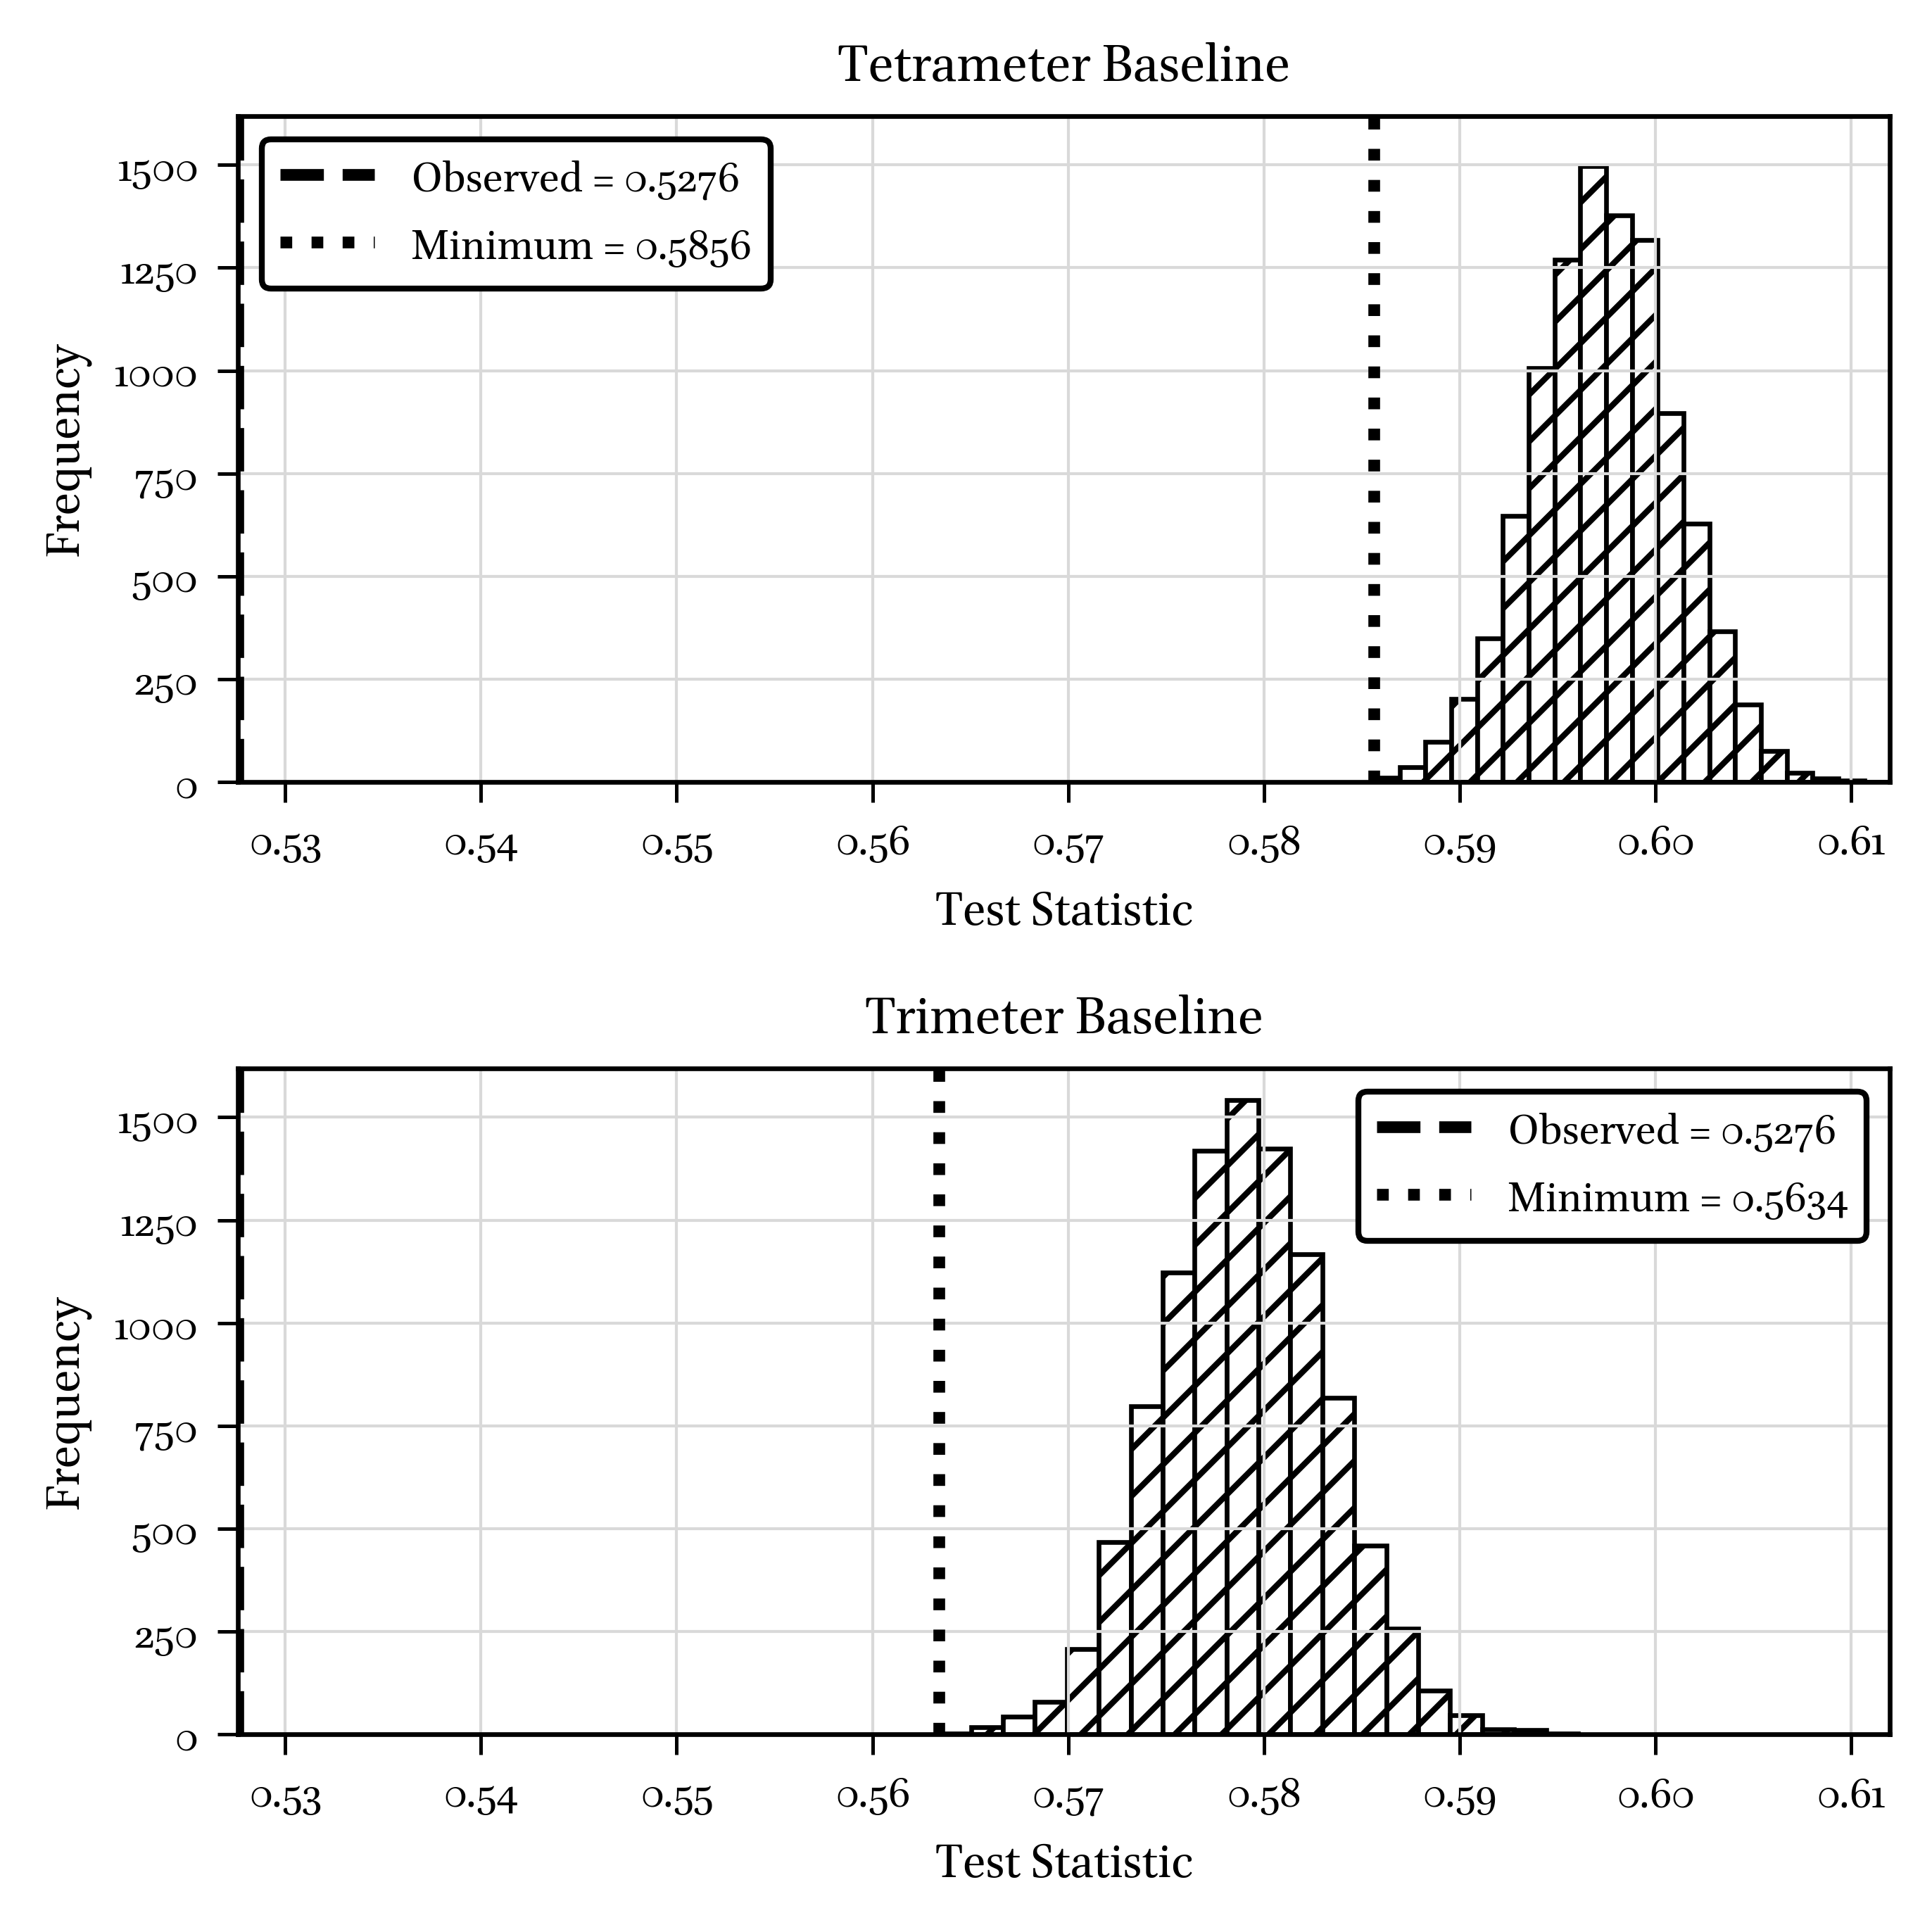

In [16]:
import matplotlib.pyplot as plt
import numpy as np

from responsio_accentuum import apply_bw_journal_style

apply_bw_journal_style()

# Convert to float arrays for plotting
T_exp_tetrameter_arr = np.array(T_exp_tetrameter_by_song, dtype=float)
T_exp_trimeter_arr = np.array(T_exp_trimeter_by_song, dtype=float)

# --- compute shared x-limits ---
xmin = min(
    np.min(T_exp_tetrameter_arr),
    np.min(T_exp_trimeter_arr),
    T_obs_triads_position,
)

xmax = max(
    np.max(T_exp_tetrameter_arr),
    np.max(T_exp_trimeter_arr),
    T_obs_triads_position,
)

fig, axes = plt.subplots(2, 1, sharey=True)

# --- histogram styling compatible with EPS + bw journal style ---
hist_kwargs = dict(
    bins=20,
    density=False,
    facecolor="white",
    edgecolor="black",
    hatch="///",
    linewidth=0.8,
)

# --- Tetrameter distribution ---
axes[0].hist(
    T_exp_tetrameter_arr,
    **hist_kwargs,
)

axes[0].axvline(
    T_obs_triads_position,
    linestyle="--",
    linewidth=2,
    label=f"Observed = {T_obs_triads_position:.4f}",
)

axes[0].axvline(
    np.min(T_exp_tetrameter_arr),
    linestyle=":",
    linewidth=2,
    label=f"Minimum = {np.min(T_exp_tetrameter_arr):.4f}",
)

axes[0].set_title("Tetrameter Baseline")
axes[0].set_xlabel("Test Statistic")
axes[0].set_ylabel("Frequency")

axes[0].legend(
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=1.0,
)

# --- Trimeter distribution ---
axes[1].hist(
    T_exp_trimeter_arr,
    **hist_kwargs,
)

axes[1].axvline(
    T_obs_triads_position,
    linestyle="--",
    linewidth=2,
    label=f"Observed = {T_obs_triads_position:.4f}",
)

axes[1].axvline(
    np.min(T_exp_trimeter_arr),
    linestyle=":",
    linewidth=2,
    label=f"Minimum = {np.min(T_exp_trimeter_arr):.4f}",
)

axes[1].set_title("Trimeter Baseline")
axes[1].set_xlabel("Test Statistic")
axes[1].set_ylabel("Frequency")
axes[1].legend(
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=1.0,
)

# --- shared x-limits ---
for ax in axes:
    ax.set_xlim(xmin, xmax)

plt.tight_layout()

# plt.savefig(ROOT / "media/figures/perm_arist/perm_arist_triads_song.eps")
# plt.savefig(
#     ROOT / "media/figures/perm_arist/perm_arist_triads_song.png",
#     dpi=600,
# )

plt.show()

## T_obs_strophes

In [17]:
T_obs_strophes_position = 0.5566
T_obs_strophes_song = 0.5593

In [18]:
import numpy as np

def permutation_p_value(T_obs, baseline):
    baseline_arr = np.asarray(baseline, dtype=float)
    ge_count = np.sum(baseline_arr >= T_obs) # ge = greater than or equal to
    return (1 + ge_count) / (1 + baseline_arr.size) # convention to add 1 to numerator and denominator to avoid zero p-value (source: https://en.wikipedia.org/wiki/P-value#Permutation_tests)

p_tetrameter_position_strophes = permutation_p_value(T_obs_strophes_position, T_exp_tetrameter_by_position)
p_trimeter_position_strophes = permutation_p_value(T_obs_strophes_position, T_exp_trimeter_by_position)
p_tetrameter_song_strophes = permutation_p_value(T_obs_strophes_song, T_exp_tetrameter_by_song)
p_trimeter_song_strophes = permutation_p_value(T_obs_strophes_song, T_exp_trimeter_by_song)

print(f"p_tetrameter_position_strophes (strophes vs tetrameter baseline): \033[1m{p_tetrameter_position_strophes:.30f}\033[0m")
print(f"p_trimeter_position_strophes (strophes vs trimeter baseline): \033[1m{p_trimeter_position_strophes:.30f}\033[0m")
print(f"p_tetrameter_song_strophes (strophes vs tetrameter baseline): \033[1m{p_tetrameter_song_strophes:.30f}\033[0m")
print(f"p_trimeter_song_strophes (strophes vs trimeter baseline): \033[1m{p_trimeter_song_strophes:.30f}\033[0m")

p_tetrameter_position_strophes (strophes vs tetrameter baseline): 1.000000000000000000000000000000
p_trimeter_position_strophes (strophes vs trimeter baseline): 1.000000000000000000000000000000
p_tetrameter_song_strophes (strophes vs tetrameter baseline): 1.000000000000000000000000000000
p_trimeter_song_strophes (strophes vs trimeter baseline): 1.000000000000000000000000000000


### Z-score

In [19]:
import numpy as np

def z_score(T_obs, baseline):
    arr = np.asarray(baseline, dtype=float)
    mu = arr.mean()
    sigma = arr.std(ddof=0)
    return (float(T_obs) - mu) / sigma if sigma != 0 else np.nan

z_tetrameter_position_strophes = z_score(T_obs_strophes_position, T_exp_tetrameter_by_position)
z_trimeter_position_strophes = z_score(T_obs_strophes_position, T_exp_trimeter_by_position)
z_tetrameter_song_strophes = z_score(T_obs_strophes_song, T_exp_tetrameter_by_song)
z_trimeter_song_strophes = z_score(T_obs_strophes_song, T_exp_trimeter_by_song)

print(f"z_trimeter_position_strophes (strophes vs trimeter baseline): {z_trimeter_position_strophes:>11.3g}")
print(f"z_trimeter_song_strophes (strophes vs trimeter baseline): {z_trimeter_song_strophes:>14.3g}")
print()
print(f"z_tetrameter_position_strophes (strophes vs tetrameter baseline): {z_tetrameter_position_strophes:>5.3g}")
print(f"z_tetrameter_song_strophes (strophes vs tetrameter baseline): {z_tetrameter_song_strophes:>11.3g}")

z_trimeter_position_strophes (strophes vs trimeter baseline):       -5.29
z_trimeter_song_strophes (strophes vs trimeter baseline):           -4.7

z_tetrameter_position_strophes (strophes vs tetrameter baseline):   -11
z_tetrameter_song_strophes (strophes vs tetrameter baseline):       -10.8


### Histogram

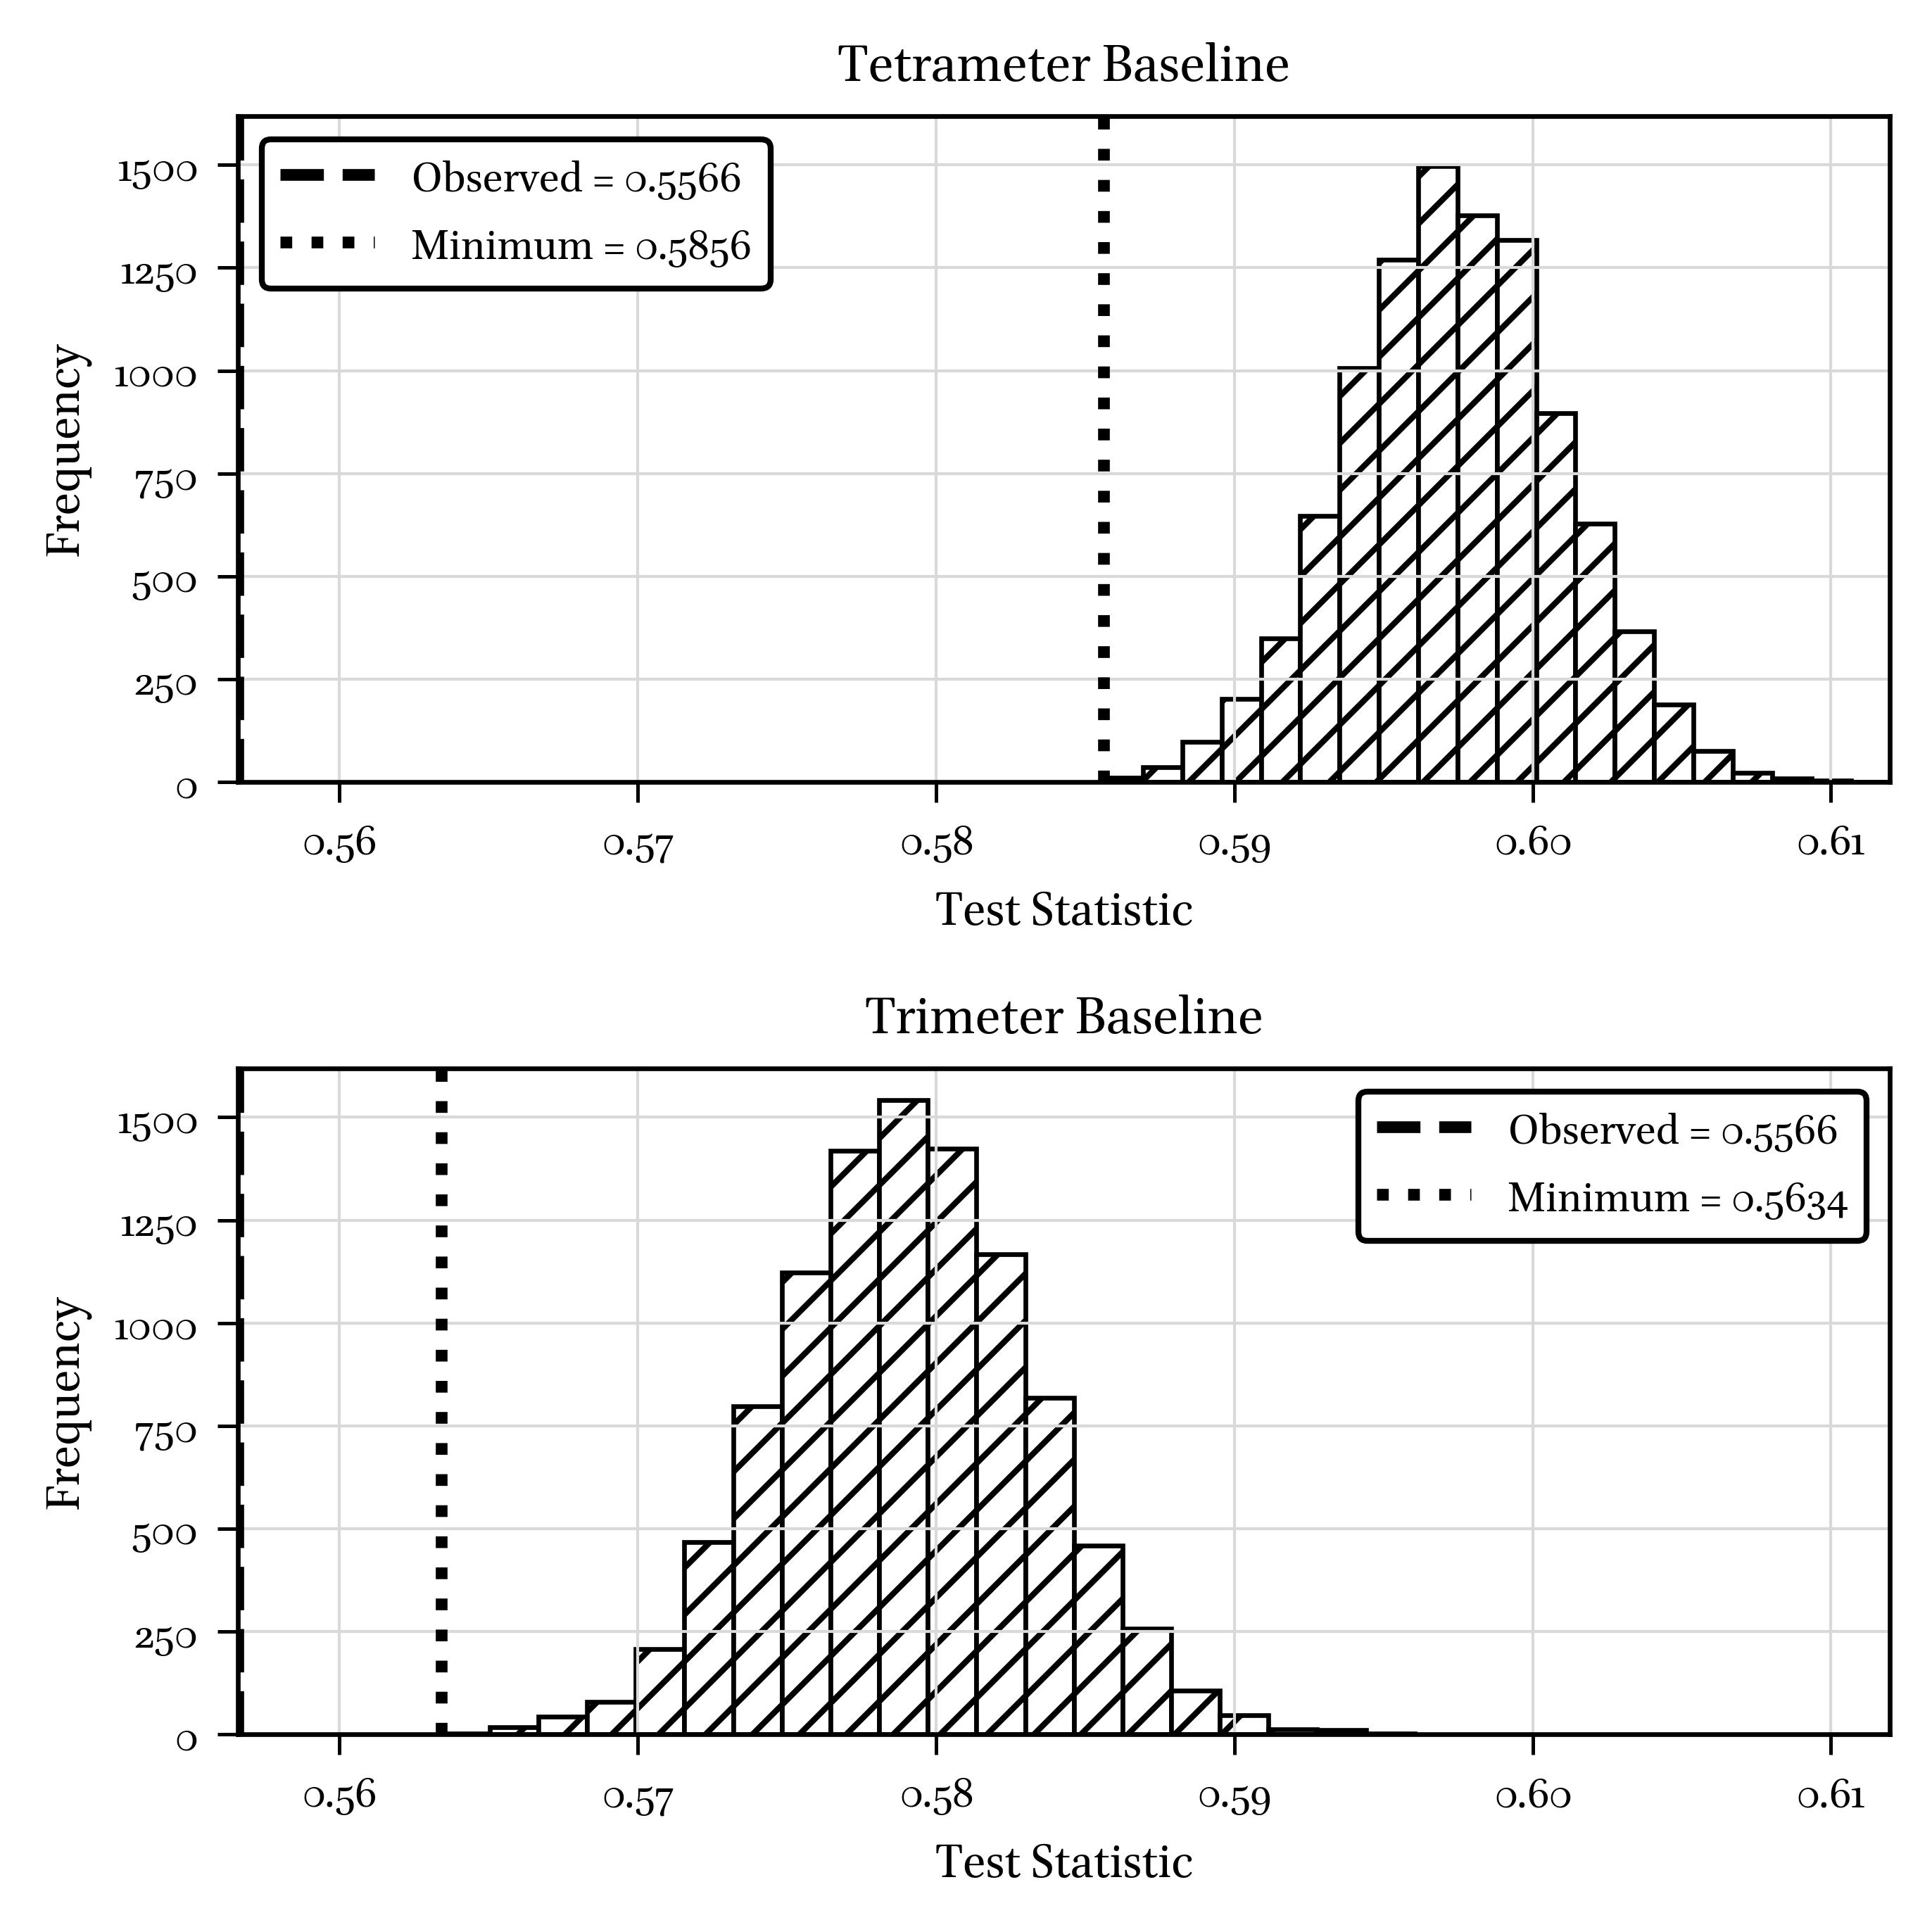

In [20]:
import matplotlib.pyplot as plt
import numpy as np

from responsio_accentuum import apply_bw_journal_style

apply_bw_journal_style()

# Convert to float arrays for plotting
T_exp_strophes_tetrameter_arr = np.array(T_exp_tetrameter_by_song, dtype=float)
T_exp_strophes_trimeter_arr = np.array(T_exp_trimeter_by_song, dtype=float)

# --- compute shared x-limits ---
xmin = min(
    np.min(T_exp_strophes_tetrameter_arr),
    np.min(T_exp_strophes_trimeter_arr),
    T_obs_strophes_position,
)

xmax = max(
    np.max(T_exp_strophes_tetrameter_arr),
    np.max(T_exp_strophes_trimeter_arr),
    T_obs_strophes_position,
)

fig, axes = plt.subplots(2, 1, sharey=True)

# --- histogram styling compatible with EPS + bw journal style ---
hist_kwargs = dict(
    bins=20,
    density=False,
    facecolor="white",
    edgecolor="black",
    hatch="///",
    linewidth=0.8,
)

# --- Tetrameter distribution ---
axes[0].hist(
    T_exp_strophes_tetrameter_arr,
    **hist_kwargs,
)

axes[0].axvline(
    T_obs_strophes_position,
    linestyle="--",
    linewidth=2,
    label=f"Observed = {T_obs_strophes_position:.4f}",
)

axes[0].axvline(
    np.min(T_exp_strophes_tetrameter_arr),
    linestyle=":",
    linewidth=2,
    label=f"Minimum = {np.min(T_exp_strophes_tetrameter_arr):.4f}",
)

axes[0].set_title("Tetrameter Baseline")
axes[0].set_xlabel("Test Statistic")
axes[0].set_ylabel("Frequency")

axes[0].legend(
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=1.0,
)

# --- Trimeter distribution ---
axes[1].hist(
    T_exp_strophes_trimeter_arr,
    **hist_kwargs,
)

axes[1].axvline(
    T_obs_strophes_position,
    linestyle="--",
    linewidth=2,
    label=f"Observed = {T_obs_strophes_position:.4f}",
)

axes[1].axvline(
    np.min(T_exp_strophes_trimeter_arr),
    linestyle=":",
    linewidth=2,
    label=f"Minimum = {np.min(T_exp_strophes_trimeter_arr):.4f}",
)

axes[1].set_title("Trimeter Baseline")
axes[1].set_xlabel("Test Statistic")
axes[1].set_ylabel("Frequency")
axes[1].legend(
    frameon=True,
    facecolor="white",
    edgecolor="black",
    framealpha=1.0,
)

# --- shared x-limits ---
for ax in axes:
    ax.set_xlim(xmin, xmax)

plt.tight_layout()

# plt.savefig(ROOT / "media/figures/perm_arist/perm_arist_strophes_song.eps")
# plt.savefig(
#     ROOT / "media/figures/perm_arist/perm_arist_strophes_song.png",
#     dpi=600,
# )

plt.show()